<font color='green'> <br>
    ***********************************************************************************************  <br><br>
    &emsp; Deep Learning Project:&emsp; Multi-class classification <br><br>
    &emsp; Author:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp; Uttara Naidu <br><br>
    &emsp; Date:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 10/02/2026 <br><br>
    &emsp; Version: &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;v0.1 (WIP) <br><br>
    &emsp; Description:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; U-NET model performance analysis <br><br>
    ***********************************************************************************************  <br>
 </font>

<font color='blue'> NOTE: This is an initial draft version. Code clean-up and optimizations will follow soon. </font>

In [1]:
""" 
    Evaluating performance metrics w.r.t to AUC and Validation Loss.
    Two models were saved during training - a) Model with lowest validation loss, b) Model with highest Precision-Recall parameters
    Out of these, model (b) is used here to obtain test accuracy, recall, precision and f1-score.
"""

import sys, warnings, json
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
""" 
    Download dataset 'covid19-radiography-database' from Kaggle
"""

try:
    with open("config.json") as f:
        js = f.read()
        json_obj = json.loads(js)

    project_path = json_obj['project_directory']

    sys.path.append(project_path)
    from scripts.data_loader import load_dataset, get_classes, get_data
    from scripts.data_preparation import prepare_dataset, one_hot_encoding
    from scripts.data_pipeline_operations import create_ds

except:
    raise Exception('Please configure the path to project directory in the file "config.json". If path is correct, then check if all imports are valid.')


2026-02-10 20:20:30.264289: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-10 20:20:30.264305: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-10 20:20:30.264308: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1770751230.264316 11297082 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770751230.264330 11297082 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
PROJ_DIR = project_path
dataset_download_dir = f'{PROJ_DIR}/data'
ROOT_DIR = load_dataset('tawsifurrahman/covid19-radiography-database', dataset_download_dir)

# Extracting class names from dataset
classes = get_classes(ROOT_DIR)

Dataset downloaded successfully at: /Users/uni/project_workspace/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5
The root directory:  /Users/uni/project_workspace/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset
Retrieveing files from:  /Users/uni/project_workspace/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset
Extracting class names ...
There are 4 available classes:

 1. COVID 
    |-- images
    |-- masks

 2. Lung_Opacity 
    |-- images
    |-- masks

 3. Normal 
    |-- images
    |-- masks

 4. Viral Pneumonia 
    |-- images
    |-- masks


In [4]:
RANDOM_STATE=42
CLASS_NAMES = list(classes.keys())

In [5]:
""" 
    Segregating the X-rays and Masks in separate lists, while maintaining their corresponding mapping to Labels (also in a separate list)
"""

dict = get_data(classes)
xrays, masks, labels = prepare_dataset(dict)
ohe_labels = one_hot_encoding(labels)
ohe_labels = np.float16(ohe_labels)

# Splitting into Train, Validation and Test sets

X_train, X_rem, M_trian, M_rem, y_train,y_rem = train_test_split(xrays,masks,ohe_labels,test_size=0.3,stratify=ohe_labels,random_state=RANDOM_STATE)

X_val, X_test, M_val, M_test, y_val, y_test = train_test_split(X_rem, M_rem, y_rem, test_size=0.5,stratify=y_rem,random_state=RANDOM_STATE )

print(' \nThe number of samples in each split are:')
print('\n - Train dataset size: ',len(X_train))
print('\n - Validation dataset size: ',len(X_val))
print('\n - Test dataset size: ',len(X_test))

LABELS:  (21165, 4)
 
The number of samples in each split are:

 - Train dataset size:  14815

 - Validation dataset size:  3175

 - Test dataset size:  3175


In [6]:
test_ds = create_ds(X_test, M_test, y_test)

Creating dataset ...
The tensor specifications for 2 features "X-rays & Masks" and 1 target variable "Labels" are: 
 ((TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None)), TensorSpec(shape=(4,), dtype=tf.float16, name=None))

The tensor specifications after pre-processing: 
 (TensorSpec(shape=(128, 128, 1), dtype=tf.float16, name=None), TensorSpec(shape=(4,), dtype=tf.float16, name=None)) 



In [7]:
# Splitting the feature and target variables for test dataset for making predictions

X_test = []
y_test = []

for img,l in test_ds.as_numpy_iterator():
    X_test.append(img)
    y_test.append(l)


print('Test data shape: ', X_test[0].shape)
print('Target variable shape: ', y_test[0].shape)

Test data shape:  (128, 128, 1)
Target variable shape:  (4,)


2026-02-10 20:20:31.448295: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
# Evaluating test dataset and making predictions

best_model = tf.keras.models.load_model(f'{PROJ_DIR}/models/128X128/auc/model.keras')

y_true_probs = np.asarray(y_test,dtype='f4')
y_true = np.argmax(y_true_probs,axis=1)

X_test = np.asarray(X_test,dtype='f4')

y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


2026-02-10 20:20:32.054044: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step


                 precision    recall  f1-score   support

          COVID       0.83      0.78      0.81       542
   LUNG_OPACITY       0.89      0.80      0.84       902
         NORMAL       0.87      0.96      0.91      1529
VIRAL_PNEUMONIA       0.98      0.85      0.91       202

       accuracy                           0.88      3175
      macro avg       0.89      0.85      0.87      3175
   weighted avg       0.88      0.88      0.87      3175



<Axes: >

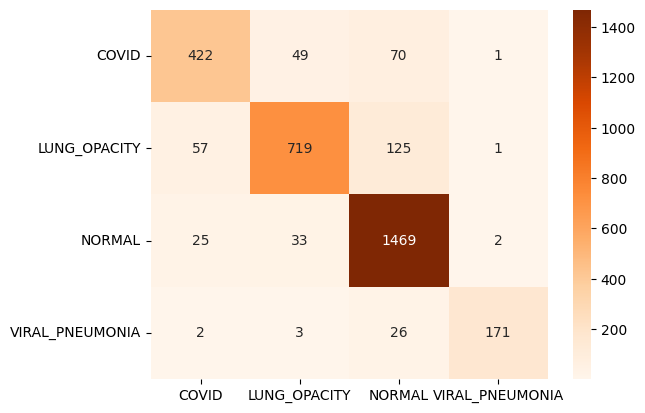

In [9]:
# Retrieving precision, recall and f1-score values since accuracy alone doesn't give a clear picture of model performance

print(classification_report(y_true,y_pred,target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm,xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,cmap='Oranges',fmt='d',annot=True)

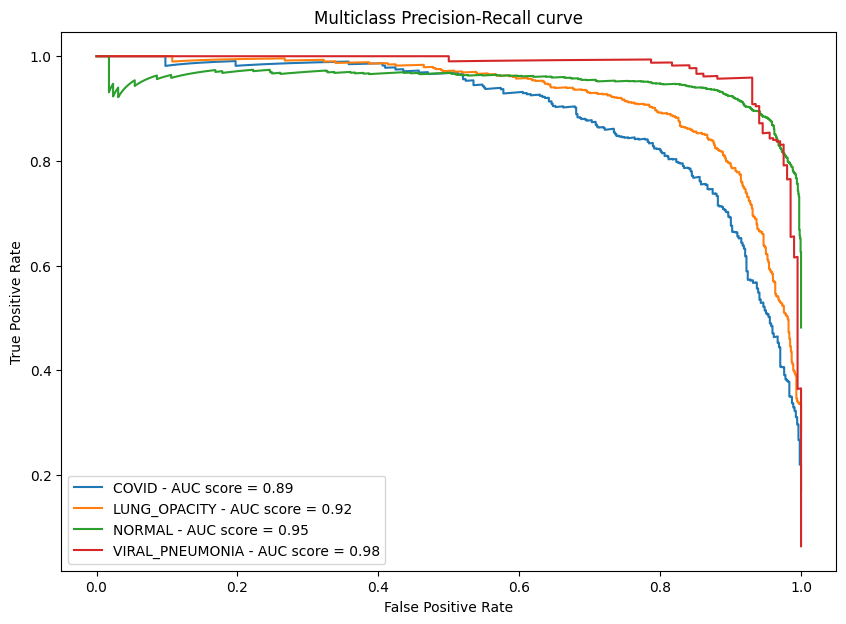

In [10]:
""" 
    Since the dataset is imbalanced - the ROC-AUC curve shows overly optimistic results. A precision-recall curve is more realistic in such cases. 
"""

plt.figure(figsize=(10,7))
for i in range(4):
    precision, recall, thresholds = precision_recall_curve(y_true_probs[:,i],y_pred_prob[:,i])
    auc_score = auc(recall,precision)
    plt.plot(recall,precision,label=f'{CLASS_NAMES[i]} - AUC score = {auc_score:.2f}')

plt.legend(loc='lower left')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass Precision-Recall curve')
plt.show()